# Leonia data lake — exploration

Code-first companion to [reports/01_exploration.md](../../reports/01_exploration.md) and [reports/09_leonia_streets.md](../../reports/09_leonia_streets.md). Loads every canonical parquet from `data/processed/` and surfaces summary tables + three interactive folium maps.

**Run time**: < 30 s end-to-end. Re-run safely from a cold kernel.

Sources used:

- `streetlight/streetscanner_segments.parquet`
- `streetlight/za_volume.parquet`
- `streetlight/za_line_shapes.parquet`
- `streetlight/bridge_od.parquet`
- `streetlight/congestion_links.parquet`
- `derived/cutthrough_index.parquet`
- `derived/hourly_profiles.parquet`
- `derived/peak_intensity_am.parquet`

In [1]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import pandas as pd

# Run from repo root regardless of where Jupyter was launched.
import os, sys
REPO = Path.cwd()
while not (REPO / 'leonia_traffic').is_dir() and REPO.parent != REPO:
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CANON = Path('data/processed/streetlight')
DERIVED = Path('data/processed/derived')
print('repo:', REPO)
print('canon dir exists:', CANON.is_dir())
print('derived dir exists:', DERIVED.is_dir())

repo: /Users/mfeldbly/code/leonia
canon dir exists: True
derived dir exists: True


## 1. Data lake inventory

Read the build manifests so we see row counts and freshness without scanning every parquet.

In [2]:
def manifest_rows(folder: Path) -> pd.DataFrame:
    mf = folder / '_manifest.json'
    if not mf.exists():
        return pd.DataFrame()
    data = json.loads(mf.read_text())
    entries = data.get('entries', {}) if isinstance(data, dict) else {}
    rows = []
    for name, meta in entries.items():
        if not isinstance(meta, dict):
            continue
        rows.append({
            'file': name,
            'rows': meta.get('rows'),
            'cols': meta.get('columns'),
            'size_kb': round((meta.get('bytes') or 0) / 1024, 1),
            'is_geo': meta.get('has_geometry', False),
            'built_at': meta.get('built_at'),
        })
    return pd.DataFrame(rows)

inv = pd.concat([
    manifest_rows(CANON).assign(scope='canonical'),
    manifest_rows(DERIVED).assign(scope='derived'),
], ignore_index=True)
inv


,file,rows,cols,size_kb,is_geo,built_at,scope
0,bridge_attributes.parquet,469,167,269.7,False,2026-05-19T15:09:05Z,canonical
1,bridge_od.parquet,469,26,22.8,False,2026-05-19T15:09:05Z,canonical
2,bridge_od_zones.parquet,14,12,16.1,True,2026-05-19T15:09:05Z,canonical
3,congestion_links.parquet,12232,34,356.7,False,2026-05-19T15:09:06Z,canonical
4,congestion_zones.parquet,136,6,39.1,True,2026-05-19T15:09:06Z,canonical
5,streetscanner_segments.parquet,9259,25,489.8,True,2026-05-19T15:09:05Z,canonical
6,za_home_distance.parquet,8082,23,138.5,False,2026-05-19T15:09:06Z,canonical
7,za_home_state.parquet,84695,17,268.0,False,2026-05-19T15:09:07Z,canonical
8,za_home_zips_top.parquet,78109,18,263.7,False,2026-05-19T15:09:06Z,canonical
9,za_line_shapes.parquet,375,13,58.0,True,2026-05-19T15:09:23Z,canonical


## 2. Top cut-through streets (derived)

From `cutthrough_index.parquet` — composite 0..1 index where 1 means worst on every sub-metric (Visitor share, non-local home share, long-trip share, speeding share).

In [3]:
ct = pd.read_parquet(DERIVED / 'cutthrough_index.parquet')
print(f'{len(ct)} residential segments scored')
show_cols = [
    'rank', 'street_name', 'osm_way_id', 'cutthrough_index',
    'thursday_volume', 'weekday_weekend_ratio',
    'non_local_home_share', 'long_trip_share_5mi', 'speeding_share',
]
ct.sort_values('cutthrough_index', ascending=False).head(15)[show_cols]

136 residential segments scored


,rank,street_name,osm_way_id,cutthrough_index,thursday_volume,weekday_weekend_ratio,non_local_home_share,long_trip_share_5mi,speeding_share
0,1,Willow Tree Road,3356462,0.590203,1298.0,3.046948,0.614,0.720,0.479
1,2,Broad Avenue,10030557,0.557284,13062.0,1.257655,0.654,0.923,0.742
2,3,Schor Avenue,17834065,0.551587,740.0,2.879377,0.519,0.719,0.526
3,4,Pine Hill Road,532511,0.512018,833.0,1.414261,0.632,0.866,0.675
4,5,Main Street,11099916,0.510843,36251.0,1.073372,0.625,0.849,0.589
5,6,Christie Heights Street,9954832,0.478515,668.0,2.726531,0.453,0.687,0.411
6,7,Nordhoff Drive,8998330,0.477537,977.0,1.447407,0.579,0.830,0.630
7,8,Hoefleys Lane,1189136,0.459765,207.0,1.604651,0.542,0.783,0.601
8,9,Lakeview Avenue,6831752,0.448596,851.0,1.379254,0.497,0.837,0.640
9,10,Fort Lee Road,590576,0.431193,14717.0,1.241522,0.509,0.816,0.530


## 3. Bridge-OD top pairs (Peak AM weekday)

In [4]:
bod = pd.read_parquet(CANON / 'bridge_od.parquet')
peak_am = bod[(bod['day_type_code'] == 1) & (bod['day_part_code'] == 2)]
print(f'{len(peak_am)} OD rows for day_type=1 (Mon) × day_part=2 (Peak AM)')
peak_am.sort_values('od_volume', ascending=False)[
    ['origin_label', 'destination_label', 'od_volume', 'avg_travel_time_sec']
].head(15)

10 OD rows for day_type=1 (Mon) × day_part=2 (Peak AM)


,origin_label,destination_label,od_volume,avg_travel_time_sec
191,Fort Lee Road,George Washington Bridge (lower level),512,1368.0
239,Fort Lee Road,George Washington Bridge (Upper Level),207,1218.0
8,Broad Avenue,George Washington Bridge (lower level),44,1616.0
381,Grand Avenue,George Washington Bridge (lower level),36,2779.0
429,Grand Avenue,George Washington Bridge (Upper Level),22,2922.0
287,Grand Avenue,George Washington Bridge (lower level),18,1712.0
54,Broad Avenue,George Washington Bridge (Upper Level),10,1086.0
99,Broad Avenue,George Washington Bridge (lower level),9,1266.0
334,Grand Avenue,George Washington Bridge (Upper Level),9,1421.0
147,Broad Avenue,George Washington Bridge (Upper Level),7,1036.0


## 4. Congestion bottlenecks (TTI ≥ 1.5)

In [5]:
cong = pd.read_parquet(CANON / 'congestion_links.parquet')
all_day = cong[(cong['day_type_code'] == 0) & (cong['day_part_code'] == 0)]
bottlenecks = (
    all_day[all_day['tti'] >= 1.5]
    .sort_values('vhd', ascending=False)
    [['osm_name', 'osm_way_id', 'road_class', 'length_mi',
      'avg_daily_volume', 'avg_speed_mph', 'tti', 'vhd']]
    .head(15)
)
print(f'{len(bottlenecks)} links with TTI ≥ 1.5 (top by VHD)')
bottlenecks

15 links with TTI ≥ 1.5 (top by VHD)


,osm_name,osm_way_id,road_class,length_mi,avg_daily_volume,avg_speed_mph,tti,vhd
2908,George Washington Bridge Plaza,590268,Motorway,0.224,56916,28.0,1.55,162.05
2991,George Washington Bridge Plaza,863503,Motorway,0.214,42946,32.0,1.50,95.96
8284,New Jersey Turnpike,861641,Motorway,0.200,31647,30.0,1.65,82.88
2359,Fort Lee Road,590577,Secondary,0.179,17496,19.0,1.62,61.57
7841,New Jersey Turnpike,24029614,Motorway,0.176,37629,37.0,1.50,60.02
5762,motorway_link,17570870,On/Off Ramp,0.187,29817,34.0,1.50,54.69
2431,Fort Lee Road,872943,Secondary,0.281,9319,20.0,1.58,47.38
2720,George Washington Bridge Plaza,3836033,Motorway,0.073,50635,28.0,1.54,46.20
2791,George Washington Bridge Plaza,4386049,Motorway,0.046,68334,27.0,1.62,44.03
10806,trunk_link,12069105,Trunk,0.238,10154,25.0,1.58,35.80


## 5. Map: Visitor volume on Leonia streets

Mon–Thu Visitor volumes from `za_volume.parquet`, joined to segment line geometries. Line thickness and colour scale with volume.

In [6]:
from leonia_traffic.viz.maps import volume_map

za = pd.read_parquet(CANON / 'za_volume.parquet')
lines = gpd.read_parquet(CANON / 'za_line_shapes.parquet')

visitor_thu = za[
    (za['filter'] == 'Visitors')
    & (za['day_type_code'] == 4)        # Thursday (canonical weekday)
    & (za['day_part_code'] == 0)        # All Day
][['zone_name', 'zone_volume']]

g = lines.merge(visitor_thu, left_on='name', right_on='zone_name', how='left')
g['zone_volume'] = g['zone_volume'].fillna(0)
print(f'{(g["zone_volume"] > 0).sum()} segments with positive Visitor volume')

volume_map(g, value_col='zone_volume', label='Visitor volume (Thu, all-day)',
           min_volume=10)

200 segments with positive Visitor volume


## 6. Map: cut-through index choropleth

Red = highest cut-through index; grey = neutral. This is the composite ranking that drives [reports/09_leonia_streets.md](../../reports/09_leonia_streets.md).

In [7]:
g2 = lines.merge(
    ct[['zone_name', 'cutthrough_index', 'rank', 'non_local_home_share',
        'speeding_share']],
    left_on='name', right_on='zone_name', how='inner',
)
print(f'{len(g2)} residential segments mapped')
volume_map(g2, value_col='cutthrough_index',
           label='Cut-through index (0..1, 1 = worst)',
           min_volume=0.0)

136 residential segments mapped


## 7. Hourly profile — top-10 cut-through streets

Visitor volume by hour-of-day for the worst-10 cut-through streets, plotted as a heatmap. Sharp peaks at 7–9 am or 4–6 pm are commuter-shortcut signatures (see also `peak_intensity_am.parquet`).

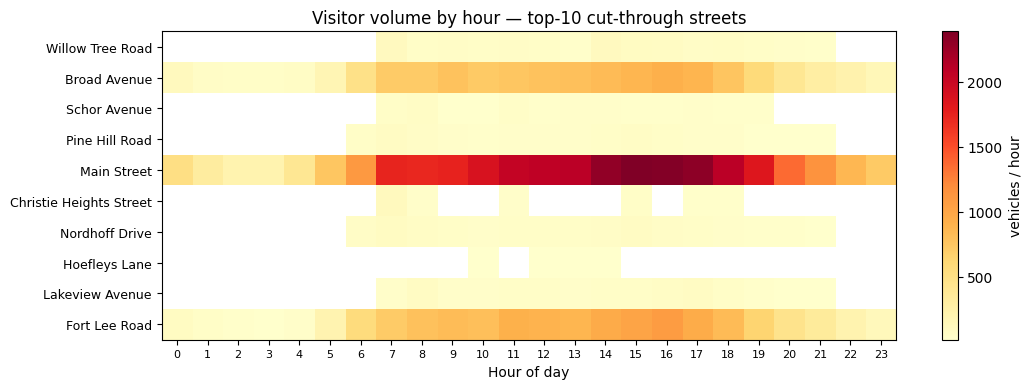

In [8]:
import matplotlib.pyplot as plt
import numpy as np

hp = pd.read_parquet(DERIVED / 'hourly_profiles.parquet')
top10 = ct.sort_values('cutthrough_index', ascending=False).head(10)
hp_top = hp.merge(top10[['zone_name', 'cutthrough_index']],
                  on='zone_name', how='inner').sort_values('cutthrough_index',
                                                            ascending=False)
hour_cols = [f'h{i:02d}' for i in range(24)]
M = hp_top[hour_cols].to_numpy(dtype=float)
labels = hp_top['street_name'].tolist()

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(M, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_xlabel('Hour of day')
ax.set_title('Visitor volume by hour — top-10 cut-through streets')
fig.colorbar(im, ax=ax, label='vehicles / hour')
plt.tight_layout()
plt.show()

## 8. Sanity check: AM-peak intensity ratios

In [9]:
pi_am = pd.read_parquet(DERIVED / 'peak_intensity_am.parquet')
print(f'{len(pi_am)} segments with AM-peak ratios')
pi_am.sort_values('peak_intensity', ascending=False).head(10)[
    ['street_name', 'osm_way_id', 'peak_per_hr', 'baseline_per_hr',
     'peak_intensity']
]

141 segments with AM-peak ratios


,street_name,osm_way_id,peak_per_hr,baseline_per_hr,peak_intensity
0,Birch Lane,8776800,39.333333,5.000000,7.866667
1,Christie Heights Street,9954832,47.666667,12.333333,3.864865
2,Walnut Street,25708088,30.666667,11.666667,2.628571
3,motorway_link,12608673,147.000000,65.333333,2.250000
4,Overlook Avenue,19311033,65.333333,34.000000,1.921569
5,Vreeland Avenue,18848062,42.333333,23.000000,1.840580
6,Grandview Terrace,19093095,87.333333,53.333333,1.637500
7,Willow Tree Road,3356462,68.000000,43.000000,1.581395
8,Van Orden Avenue,19616618,36.333333,23.333333,1.557143
9,Glenwood Avenue,429389,189.333333,122.333333,1.547684


## Next steps

- **[02_scenario_sandbox.ipynb](02_scenario_sandbox.ipynb)** — interactive what-if assignment (close streets, reduce capacity, see diversion).
- **[03_recommendations.ipynb](03_recommendations.ipynb)** — rule-based recommendations with diversion-impact estimates.